In [ ]:
import yfinance as yf

# Download Reliance stock data
df = yf.download("RELIANCE.NS",
                   start="2020-01-01",
                   end="2025-01-01")

# Save dataset as CSV
df.to_csv("reliance_stock_data.csv")

print("Dataset saved successfully")

/tmp/ipykernel_3511/2981271512.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("RELIANCE.NS",
[*********************100%***********************]  1 of 1 completed

Dataset saved successfully


In [ ]:
from google.colab import files

files.download("reliance_stock_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2020-01-01,675.324219,683.152914,673.490123,679.081997,14004468
2020-01-02,686.821289,689.348852,676.397959,676.397959,17710316
2020-01-03,687.648804,689.661895,681.318729,685.792252,20984698
2020-01-06,671.700623,683.510705,670.134872,679.976657,24519177
2020-01-07,682.034546,686.463335,677.068889,679.529321,16683622


In [ ]:
df.reset_index(inplace=True)

In [ ]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1238 entries, 0 to 1237
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   (Date, )               1238 non-null   datetime64[ns]
 1   (Close, RELIANCE.NS)   1238 non-null   float64       
 2   (High, RELIANCE.NS)    1238 non-null   float64       
 3   (Low, RELIANCE.NS)     1238 non-null   float64       
 4   (Open, RELIANCE.NS)    1238 non-null   float64       
 5   (Volume, RELIANCE.NS)  1238 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 58.2 KB
None


In [ ]:
df.isnull().sum()

,,0
Price,Ticker,
Close,RELIANCE.NS,0
High,RELIANCE.NS,0
Low,RELIANCE.NS,0
Open,RELIANCE.NS,0
Volume,RELIANCE.NS,0


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
df = df.sort_values(by='Date')

In [ ]:
print(df.head())
print(df.shape)

Price      index       Close        High         Low        Open      Volume
Ticker           RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS
Date                                                                        
2020-01-01     0  675.324219  683.152914  673.490123  679.081997    14004468
2020-01-02     1  686.821289  689.348852  676.397959  676.397959    17710316
2020-01-03     2  687.648804  689.661895  681.318729  685.792252    20984698
2020-01-06     3  671.700623  683.510705  670.134872  679.976657    24519177
2020-01-07     4  682.034546  686.463335  677.068889  679.529321    16683622
(1238, 6)


In [ ]:
print(df.dtypes)

Price   Ticker     
index                    int64
Close   RELIANCE.NS    float64
High    RELIANCE.NS    float64
Low     RELIANCE.NS    float64
Open    RELIANCE.NS    float64
Volume  RELIANCE.NS      int64
dtype: object


In [ ]:
df.to_csv("cleaned_reliance_stock_data.csv")

In [ ]:
import matplotlib.pyplot as plt

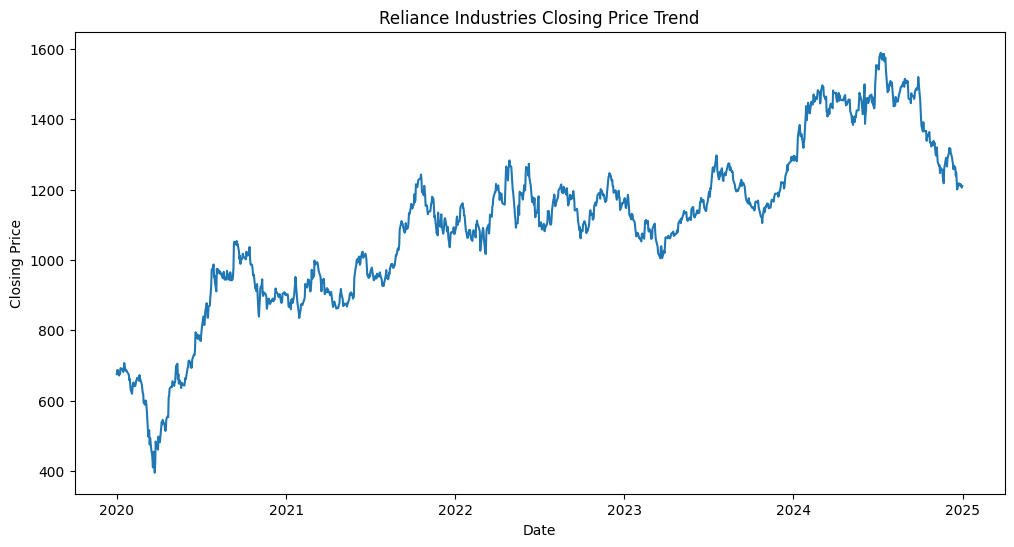

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df['Close'])

plt.title("Reliance Industries Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.show()

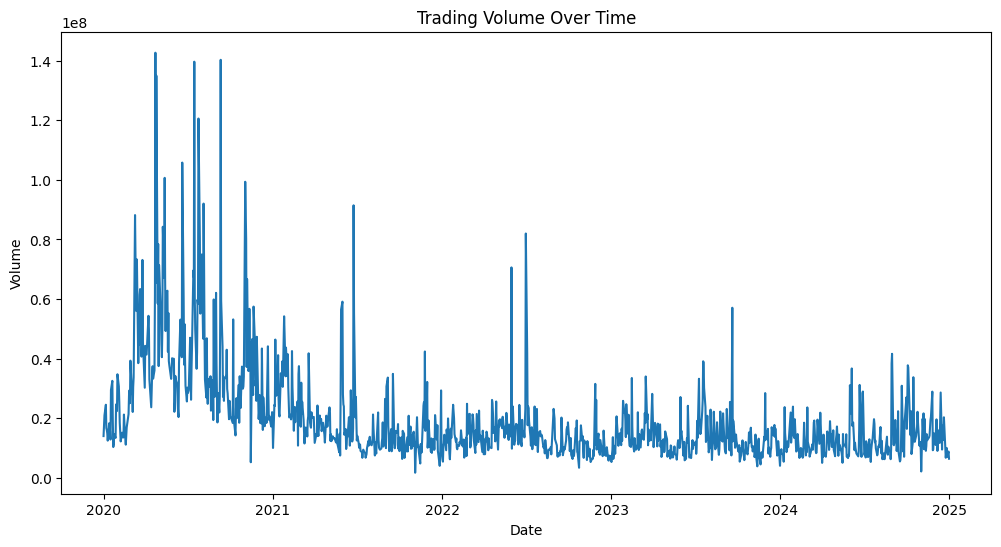

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df['Volume'])

plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.show()

In [ ]:
df['MA_10'] = df['Close'].rolling(window=10).mean()
df['MA_30'] = df['Close'].rolling(window=30).mean()

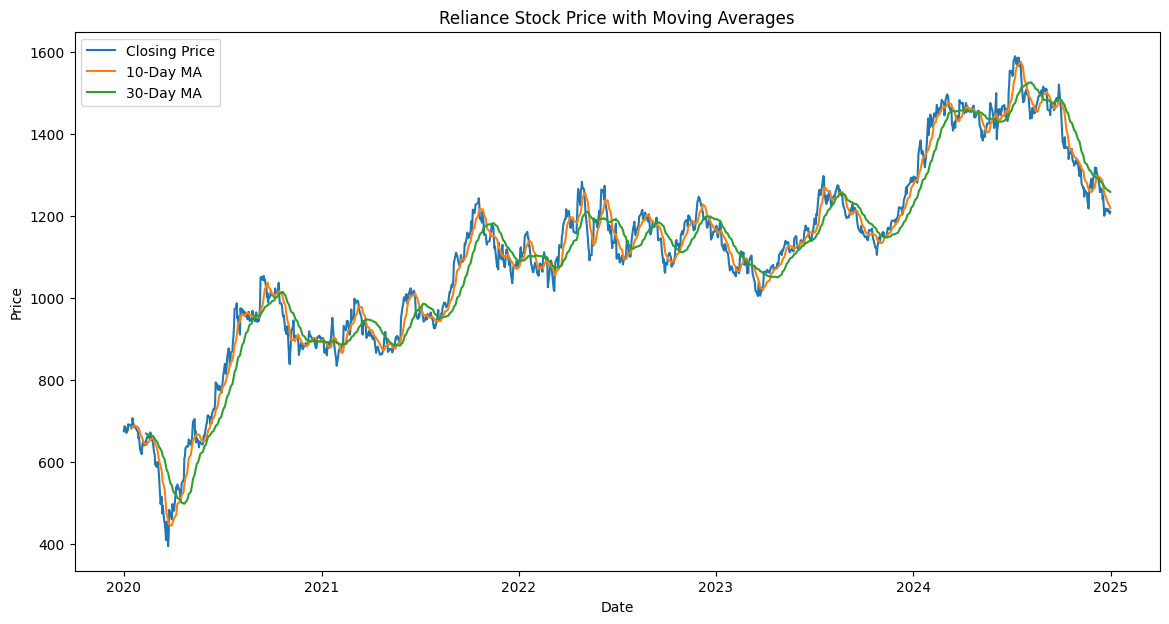

In [ ]:
plt.figure(figsize=(14,7))

plt.plot(df['Close'], label='Closing Price')
plt.plot(df['MA_10'], label='10-Day MA')
plt.plot(df['MA_30'], label='30-Day MA')

plt.title("Reliance Stock Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.show()


In [ ]:
df['Daily_Return'] = df['Close'].pct_change()

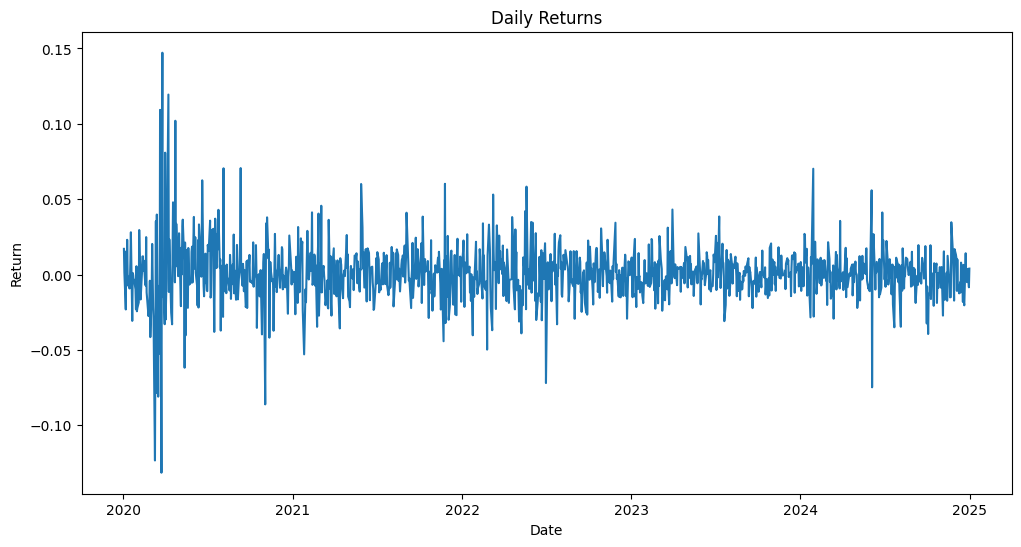

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df['Daily_Return'])

plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")

plt.show()

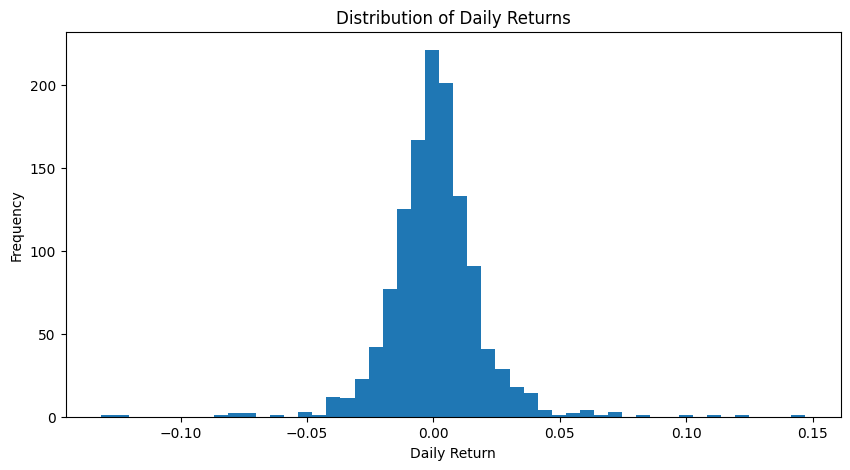

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(df['Daily_Return'].dropna(), bins=50)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [ ]:
print(df.corr())

Price                        index       Close        High         Low  \
Ticker                             RELIANCE.NS RELIANCE.NS RELIANCE.NS   
Price        Ticker                                                      
index                     1.000000    0.887873    0.886063    0.890052   
Close        RELIANCE.NS  0.887873    1.000000    0.999082    0.999023   
High         RELIANCE.NS  0.886063    0.999082    1.000000    0.998605   
Low          RELIANCE.NS  0.890052    0.999023    0.998605    1.000000   
Open         RELIANCE.NS  0.887851    0.997576    0.998883    0.998787   
Volume       RELIANCE.NS -0.493785   -0.488810   -0.476332   -0.502978   
MA_10                     0.892982    0.991907    0.993004    0.992699   
MA_30                     0.901680    0.971923    0.973018    0.973064   
Daily_Return             -0.031684    0.007530   -0.018966   -0.020514   

Price                           Open      Volume     MA_10     MA_30  \
Ticker                   RELIANCE.NS RE

In [ ]:
print(df.describe())

Price         index        Close         High          Low         Open  \
Ticker               RELIANCE.NS  RELIANCE.NS  RELIANCE.NS  RELIANCE.NS   
count   1238.000000  1238.000000  1238.000000  1238.000000  1238.000000   
mean     618.500000  1100.161475  1112.124802  1089.250152  1101.029339   
std      357.524125   231.543413   231.765306   231.155857   231.430428   
min        0.000000   395.482544   424.985478   391.724765   409.864925   
25%      309.250000   955.397797   966.569691   946.793368   955.971028   
50%      618.500000  1120.744751  1133.024582  1111.124282  1122.160070   
75%      927.750000  1224.963013  1238.659281  1213.518228  1224.827693   
max     1237.000000  1589.138062  1596.980044  1573.851280  1592.662006   

Price         Volume        MA_10        MA_30 Daily_Return  
Ticker   RELIANCE.NS                                         
count   1.238000e+03  1229.000000  1209.000000  1237.000000  
mean    1.951391e+07  1101.279572  1103.447643     0.000647  
s

In [ ]:
X = df[['Open', 'High', 'Low', 'Volume']]

y = df['Close']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
predictions = model.predict(X_test)

In [ ]:
import pandas as pd

In [ ]:
comparison = pd.DataFrame({
    'Actual': y_test.values.ravel(),
    'Predicted': predictions.ravel()
})

print(comparison.head())

        Actual    Predicted
0  1175.796631  1165.759765
1  1051.847046  1047.903070
2  1194.058228  1191.105113
3  1163.414062  1163.137594
4  1208.033691  1201.722874


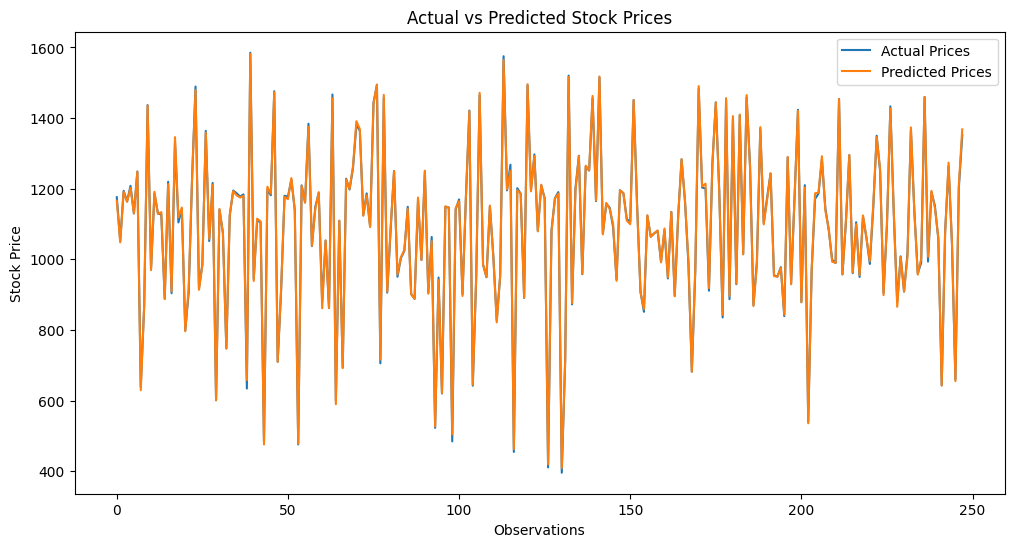

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual Prices')
plt.plot(predictions, label='Predicted Prices')

plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Observations")
plt.ylabel("Stock Price")

plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = mse ** 0.5

r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 4.48904474344347
RMSE: 5.966350343849553
R2 Score: 0.999323988248844


In [ ]:
future_data = pd.DataFrame({
    'Open': [1450],
    'High': [1475],
    'Low': [1440],
    'Volume': [5000000]
})

In [ ]:
future_prediction = model.predict(future_data)

print("Predicted Closing Price:", future_prediction[0])

Predicted Closing Price: [1462.73161634]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


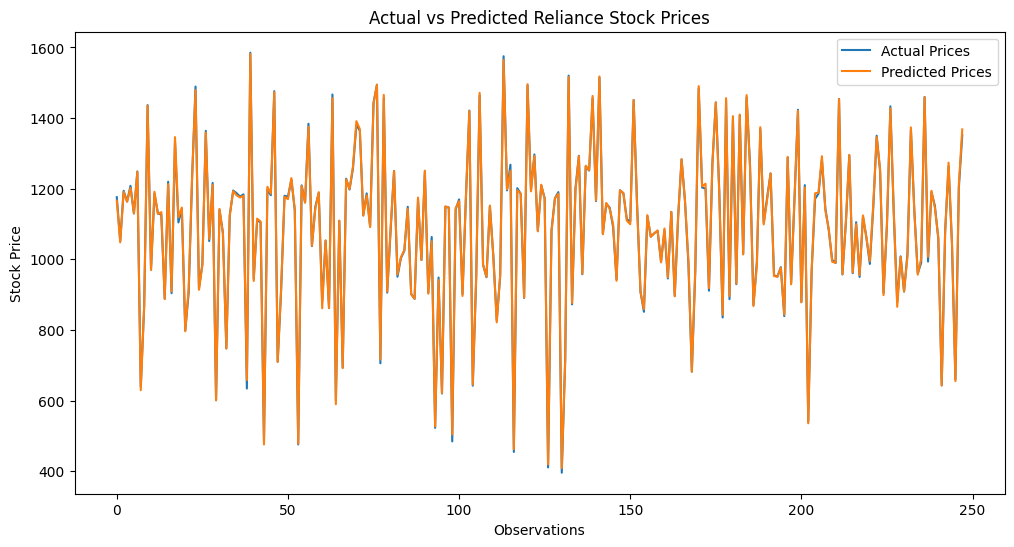

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual Prices')

plt.plot(predictions, label='Predicted Prices')

plt.title("Actual vs Predicted Reliance Stock Prices")

plt.xlabel("Observations")

plt.ylabel("Stock Price")

plt.legend()

plt.show()

In [ ]:
comparison.to_csv("reliance_predictions.csv", index=False)

In [ ]:
df.to_csv("reliance_cleaned_data.csv")
comparison.to_csv("reliance_predictions.csv", index=False)

In [ ]:
from google.colab import files

files.download("reliance_cleaned_data.csv")
files.download("reliance_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
comparison = pd.DataFrame({
    'Date': y_test.index,
    'Actual': y_test.values.ravel(),
    'Predicted': predictions.ravel()
})

comparison.to_csv("reliance_predictions.csv", index=False)